
# Introduction to Plots.jl
This guide provides an introduction to [Plots.jl](https://docs.juliaplots.org/stable/), a powerful and flexible plotting package for Julia.
Plots.jl is a widely used Julia package for data visualization.

In [1]:
using Plots
using Plots.RecipesBase: @recipe, @shorthands
using LaTeXStrings


To plot a given function, we can pass it as an argument to the `plot` function.



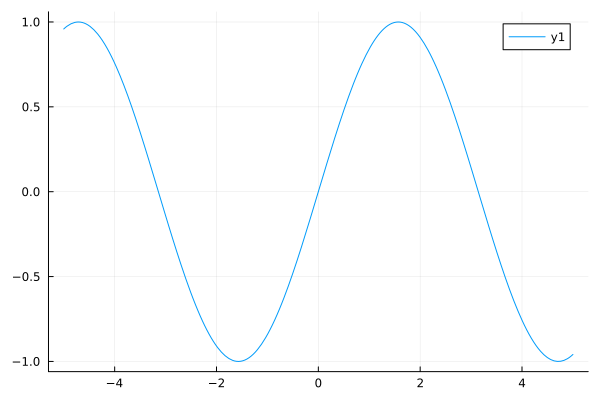

In [2]:
plot(sin)


Additionally, we can provide x-coordinates (`x`) and y-coordinates (`y`) as arguments to the `plot` function to create custom plots.


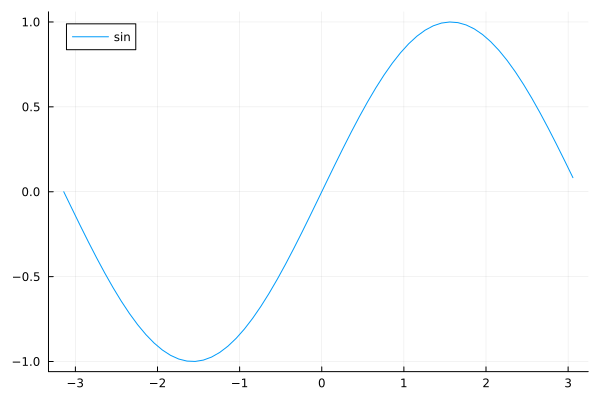

In [3]:
x = -π:0.1:π
y = sin.(x)
# line plot
plot(x, y, label="sin")


We can draw multiple functions on a same plot pane using `plot!` function.
The following example demonstrates plotting the sine function $y = \sin(x)$ for $x \in [-\pi, \pi]$.



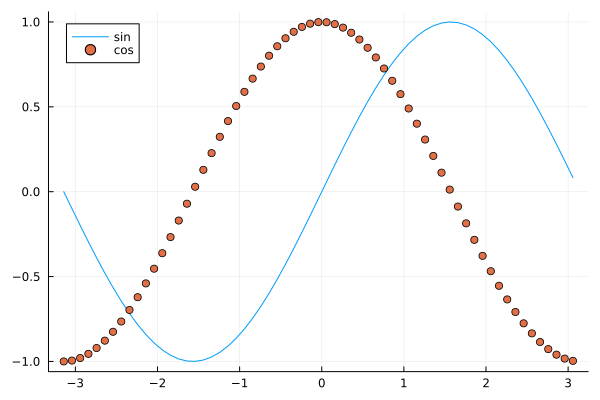

In [4]:
x = -π:0.1:π
y1 = sin.(x)
y2 = cos.(x)
plt = plot()
# line plot
plot!(plt, x, y1, label="sin")
# scatter plot
plot!(plt, x, y2, label="cos", seriestype=:scatter)


Instead of specifying `seriestype=:scatter`, we can use the `scatter` or `scatter!` functions directly.



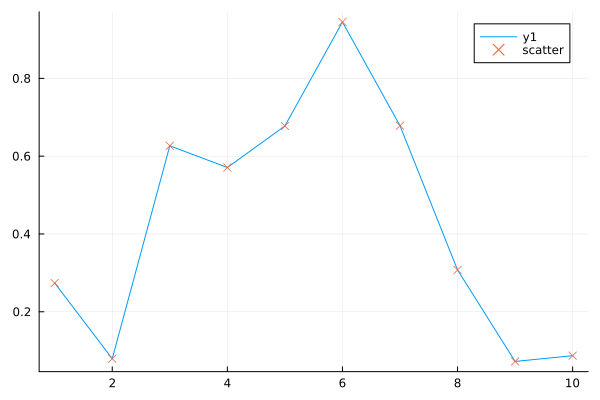

In [5]:
x = 1:10
y = rand(10)
plt = plot()
plot!(x, y)
scatter!(x, y, label="scatter", marker=:x)


## Heatmap

We can use the `heatmap` function to visualize a function on a two-dimensional domain.



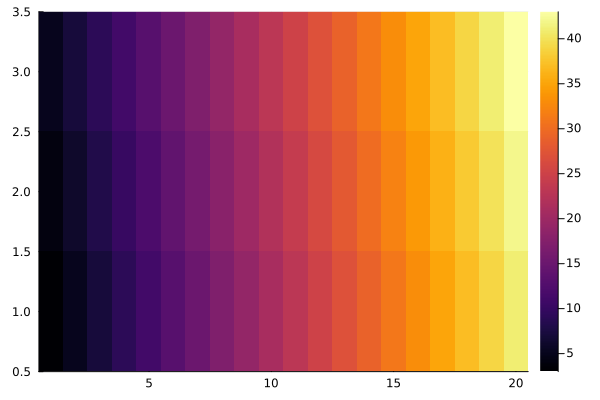

In [6]:
x = 1:20
y = 1:3
f(x, y) = 2x + y
heatmap(x, y, f)


Of course, we can also pass the z-coordinates of the data (`z`) as the third argument to the `heatmap` function.



size(f.(x', y)) = (3, 20)


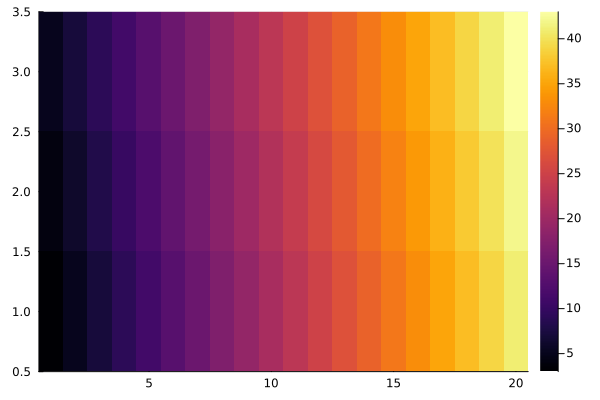

In [7]:
x = 1:20
y = 1:3
f(x, y) = 2x + y
@show size(f.(x', y))
z = f.(x', y)
heatmap(x, y, z)


## Defining a custom seriestype

We can define a custom seriestype by creating a new struct and defining a [recipe](https://docs.juliaplots.org/stable/recipes/#recipes) for it.
Here we define a custom seriestype `SemiLogy` that plots the y-axis on a logarithmic scale.



In [8]:
# defines mutable struct `SemiLogy` and sets shorthands
# `semilogy` and `semilogy!`
@userplot SemiLogy
@recipe function f(t::SemiLogy)
    x = t.args[begin]
    y = t.args[end]
    ε = nextfloat(0.0)
    yscale := :log10
    # Adding ε avoids getting log10(0) from being -Inf
    (x, ε .+ y)
end

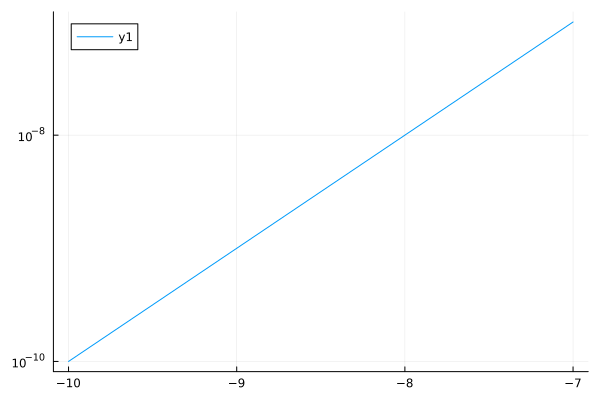

In [9]:
semilogy((-10:1:-7), 10.0 .^ (-10:1:-7))